<a href="https://colab.research.google.com/github/princedanson/Intermidiate_1/blob/main/tutorials/contact_5/Spam_dectection_model_revamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [175]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,accuracy_score,
                             precision_score,recall_score,f1_score,classification_report,roc_auc_score)

In [176]:
path = kagglehub.dataset_download("venky73/spam-mails-dataset")
files = os.listdir(path)
for file in files:
    if file.endswith(".csv"):
        path = os.path.join(path, file)
        break
df = pd.read_csv(path)

Using Colab cache for faster access to the 'spam-mails-dataset' dataset.


In [177]:
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [178]:
df.value_counts('label_num')

,count
label_num,
0,3672
1,1499


In [179]:
#Getting all the columns names
COLS = [col for col in df.columns if col != 'Unnamed: 0']
COLS

['label', 'text', 'label_num']

In [180]:
#df['label'] = df['label'].str.lower().map({'spam':0, "ham":1})

In [181]:
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [182]:
#checking for
df.isna().any()

,0
Unnamed: 0,False
label,False
text,False
label_num,False


In [183]:
#Dropping unnecessary columns and seprating target and featurs
x = df.drop(['Unnamed: 0','label_num'],axis=1)
y = df['label_num']
x

,label,text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...
...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...
5169,ham,Subject: industrial worksheets for august 2000...


In [184]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [193]:
pipeline = {
    'Logistic Regression':Pipeline([
        ('tfidf',TfidfVectorizer()),
        ('lr',LogisticRegression(class_weight='balanced', random_state=42))
    ]),
    'RandomForestClassifier':Pipeline([
        ('tfidf',TfidfVectorizer()),
        ('rf',RandomForestClassifier())
    ]),
    'SVC':Pipeline([
        ('tfidf',TfidfVectorizer()),
        ('svc',SVC())
    ]),
    'Bayes Classifier':Pipeline([
        ('tfidf',TfidfVectorizer()),
        ('nb',MultinomialNB())
    ])
}
result={}
result1 ={}



Model Name: Logistic Regression
Accuracy Score: 0.9681159420289855
Precision Score: 0.9012345679012346
Recall Score: 0.9965870307167235
F1 Score: 0.9619018829873028
ROC AUC Score: 0.9767301730403024


Model Name: Logistic Regression
              precision    recall  f1-score   support

    Not Spam       1.00      0.96      0.98       742
        Spam       0.90      1.00      0.95       293

    accuracy                           0.97      1035
   macro avg       0.95      0.98      0.96      1035
weighted avg       0.97      0.97      0.97      1035





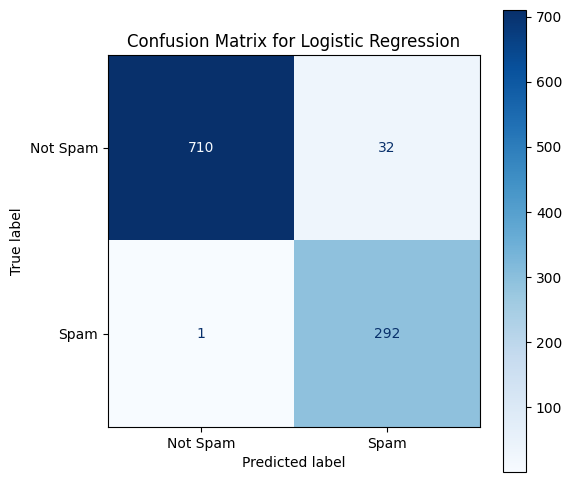





Model Name: RandomForestClassifier
Accuracy Score: 0.9729468599033816
Precision Score: 0.974910394265233
Recall Score: 0.9283276450511946
F1 Score: 0.9661786811319522
ROC AUC Score: 0.9594468413935218


Model Name: RandomForestClassifier
              precision    recall  f1-score   support

    Not Spam       0.97      0.99      0.98       742
        Spam       0.97      0.93      0.95       293

    accuracy                           0.97      1035
   macro avg       0.97      0.96      0.97      1035
weighted avg       0.97      0.97      0.97      1035





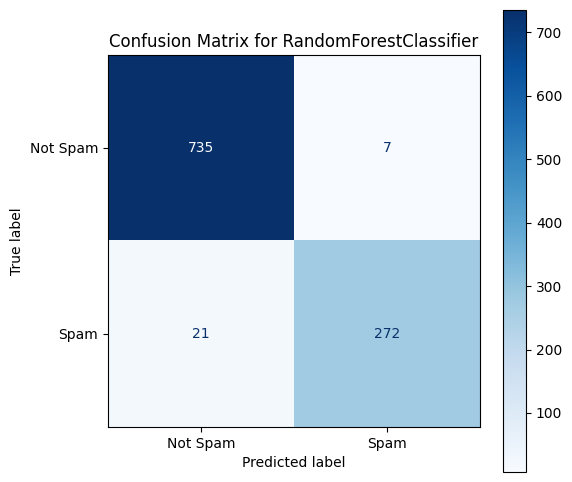





Model Name: SVC
Accuracy Score: 0.9855072463768116
Precision Score: 0.9602649006622517
Recall Score: 0.9897610921501706
F1 Score: 0.9823102122204814
ROC AUC Score: 0.9867942927058132


Model Name: SVC
              precision    recall  f1-score   support

    Not Spam       1.00      0.98      0.99       742
        Spam       0.96      0.99      0.97       293

    accuracy                           0.99      1035
   macro avg       0.98      0.99      0.98      1035
weighted avg       0.99      0.99      0.99      1035





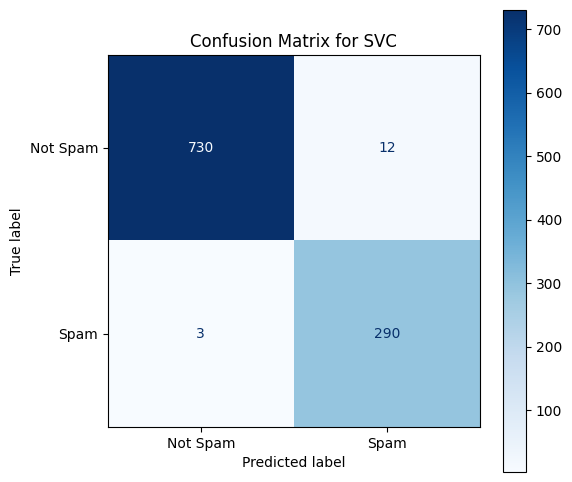





Model Name: Bayes Classifier
Accuracy Score: 0.8772946859903382
Precision Score: 1.0
Recall Score: 0.5665529010238908
F1 Score: 0.8222392619369288
ROC AUC Score: 0.7832764505119454


Model Name: Bayes Classifier
              precision    recall  f1-score   support

    Not Spam       0.85      1.00      0.92       742
        Spam       1.00      0.57      0.72       293

    accuracy                           0.88      1035
   macro avg       0.93      0.78      0.82      1035
weighted avg       0.90      0.88      0.87      1035





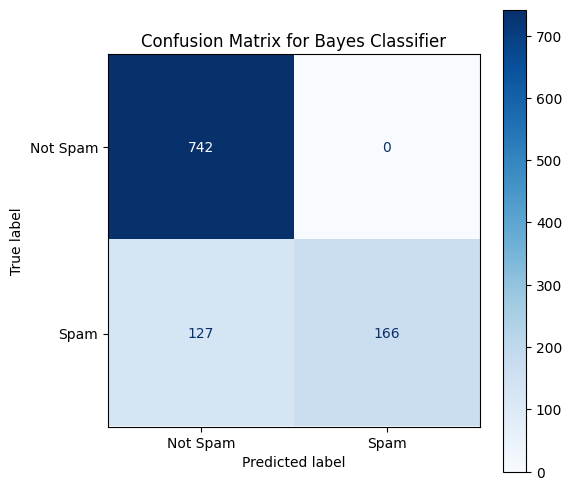

In [207]:
for Model_name,model in pipeline.items():
    model.fit(x_train['text'],y_train)
    y_pred = model.predict(x_test['text'])

    Model_accuracy = accuracy_score(y_test,y_pred)
    Model_precision = precision_score(y_test,y_pred)
    Model_recall = recall_score(y_test,y_pred)
    Model_f1_score = f1_score(y_test,y_pred, average='macro')
    Model_roc_auc_score = roc_auc_score(y_test,y_pred)
    result[Model_name] = {
        'Accuracy Score':Model_accuracy,
        'Precision Score':Model_precision,
        'Recall Score':Model_recall,
        'F1 Score':Model_f1_score,
        'ROC AUC Score':Model_roc_auc_score
    }
    result1[Model_name] = Model_f1_score

    print("\n")
    print(f"Model Name: {Model_name}")
    print(f"Accuracy Score: {Model_accuracy}")
    print(f"Precision Score: {Model_precision}")
    print(f"Recall Score: {Model_recall}")
    print(f"F1 Score: {Model_f1_score}")
    print(f"ROC AUC Score: {Model_roc_auc_score}")
    print("\n")
    print(f'Model Name: {Model_name}')
    print(classification_report(y_test,y_pred, target_names=['Not Spam','Spam']))
    print("\n")

    cm = confusion_matrix(y_test,y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Not Spam','Spam'])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Not Spam','Spam'])

    fig,ax = plt.subplots(figsize=(6,6))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix for {Model_name}")
    disp.plot(ax=ax ,cmap=plt.cm.Blues, values_format='d')
    plt.show()

    print("\n")


In [187]:
best_model = max(result, key=lambda model_name: result[model_name]['F1 Score'])
print(f"Best Model: {best_model}")

Best Model: SVC


In [188]:
best_score_1 = max( result1,key= result1.get)
print(f"Best Model: {best_score_1}")

Best Model: SVC
